# 03 — Demand-side contributions to GDP growth
**Different question from notebook 02.** Notebook 02 asked *what best **predicts** GDP* (a
modelling question). This notebook asks *what **accounted for** each quarter's growth* — the
expenditure-side decomposition that is an **accounting identity**, not a model.

GDP growth = contribution of PFCE + GFCE + GFCF + Changes-in-Stocks + Valuables +
Net-Exports + Discrepancies. These are the `c_*` columns — the same ones we *excluded* from
the predictive model (they'd be leakage there) but which are exactly right here.

Source: `data/interim/gdp_growth_contributions_quarterly.csv` (2011-12 base, the series for
which official contribution breakdowns are published).

## 0 · Setup

In [6]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi":110, "savefig.dpi":150, "savefig.bbox":"tight",
                     "axes.titleweight":"bold"})

# Project root auto-resolves — no edit needed after cloning/moving.
# (Set env var GDP_PROJECT to override; otherwise walk up to find the repo.)
import os
PROJECT = Path(os.environ.get("GDP_PROJECT", "")).expanduser()
if not (PROJECT / "data").is_dir():
    here = Path.cwd()
    for cand in (here, *here.parents):
        if (cand / "data" / "processed").is_dir() or (cand / "src").is_dir():
            PROJECT = cand
            break
print("project:", PROJECT)

FIGS = PROJECT/"outputs"/"figures"; FIGS.mkdir(parents=True, exist_ok=True)
g = pd.read_csv(PROJECT/"data"/"interim"/"gdp_growth_contributions_quarterly.csv")
g = g.dropna(subset=["GDP_growth_pct"]).reset_index(drop=True)

order_key = lambda q: int(q[:4])*4 + int(q[-1])
g = g.sort_values("FY_Quarter", key=lambda s: s.map(order_key)).reset_index(drop=True)

COMPONENTS = ["c_PFCE","c_GFCE","c_GFCF","c_CIS","c_Valuables","c_NetExports","c_Discrepancies"]
NICE = {"c_PFCE":"Private consumption","c_GFCE":"Govt consumption","c_GFCF":"Investment (GFCF)",
        "c_CIS":"Change in stocks","c_Valuables":"Valuables","c_NetExports":"Net exports",
        "c_Discrepancies":"Discrepancies"}

# sanity: components must sum to headline growth
chk = (g[COMPONENTS].sum(axis=1) - g["GDP_growth_pct"]).abs().max()
print(f"{len(g)} quarters | max |sum(components) - GDP growth| = {chk:.3f}  (rounding only)")
g[["FY_Quarter","GDP_growth_pct"]+COMPONENTS].tail(4)

54 quarters | max |sum(components) - GDP growth| = 0.020  (rounding only)


,FY_Quarter,GDP_growth_pct,c_PFCE,c_GFCE,c_GFCF,c_CIS,c_Valuables,c_NetExports,c_Discrepancies
50,2024-25 Q3,6.37,4.82,0.72,1.68,0.06,-0.01,2.79,-3.69
51,2024-25 Q4,7.38,3.20,-0.20,3.13,0.09,-0.39,3.66,-2.10
52,2025-26 Q1,7.81,4.03,0.70,2.70,0.10,-0.11,-1.38,1.77
53,2025-26 Q2,8.23,4.46,-0.24,2.54,0.13,-0.67,-2.08,4.09


## 1 · The decomposition chart
Each bar is one quarter's GDP growth split into its demand-side contributions (in percentage
points). Bars below zero are drags (e.g. imports inside net-exports, or negative
discrepancies). The black line is total GDP growth — it equals the stacked bar by
construction.

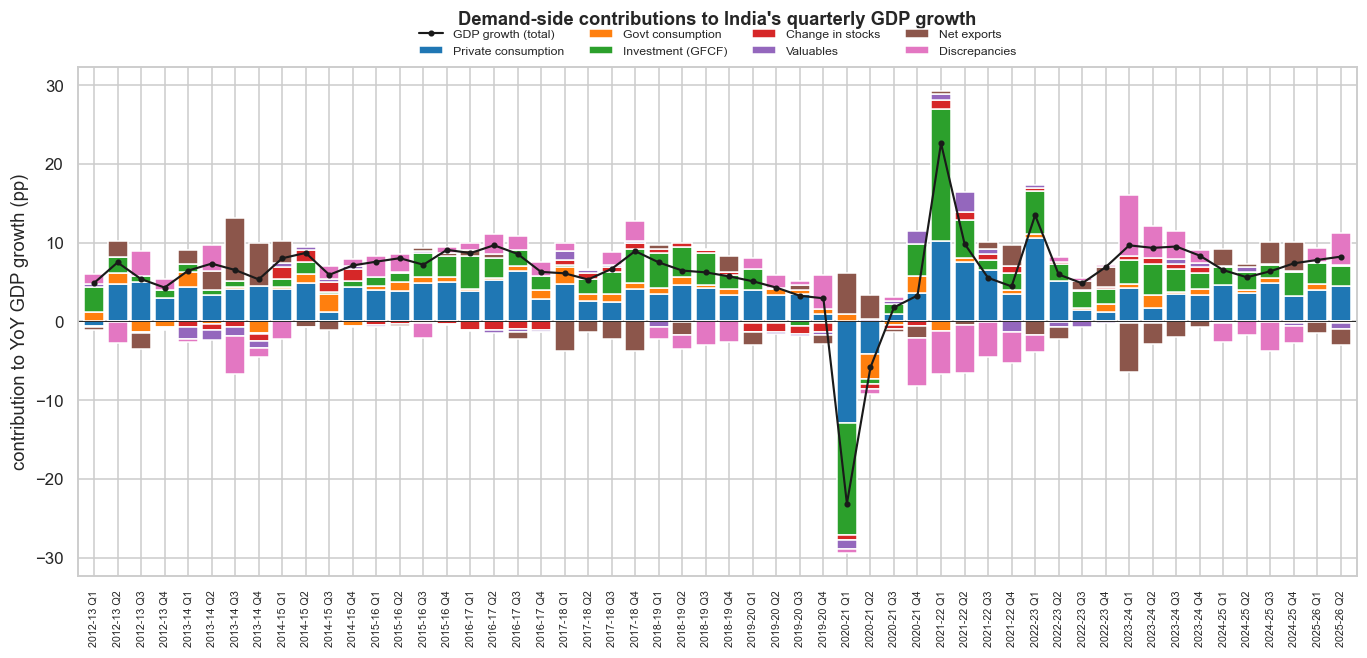

In [7]:
fig, ax = plt.subplots(figsize=(15, 6))
data = g[COMPONENTS].rename(columns=NICE)
data.index = g["FY_Quarter"]
palette = sns.color_palette("tab10", len(COMPONENTS))
data.plot(kind="bar", stacked=True, ax=ax, color=palette, width=0.85, legend=True)
ax.plot(range(len(g)), g["GDP_growth_pct"].values, "k-o", ms=3, lw=1.4, label="GDP growth (total)")
ax.axhline(0, color="k", lw=0.6)
ax.set_ylabel("contribution to YoY GDP growth (pp)")
ax.set_xlabel(""); ax.set_xticklabels(g["FY_Quarter"], rotation=90, fontsize=7)
ax.legend(ncol=4, fontsize=8, frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.0))
ax.set_title("Demand-side contributions to India's quarterly GDP growth", pad=28)
fig.savefig(FIGS/"03b_contributions_stacked.png"); plt.show()

## 2 · Average contribution by regime
Averaging contributions over three regimes — pre-COVID, the COVID shock year, and the
recovery/recent period — shows which components *carry* growth and which are volatile.

regime               Pre-COVID (FY13-FY20)  COVID (FY21)  Recovery/recent (FY22-FY26)
Private consumption                   3.78         -3.15                         4.67
Govt consumption                      0.57         -0.12                         0.32
Investment (GFCF)                     1.76         -2.37                         3.51
Change in stocks                     -0.09         -0.57                         0.46
Valuables                            -0.11          0.31                         0.07
Net exports                           0.21          1.60                        -0.12
Discrepancies                         0.48         -1.68                        -0.44
GDP growth                            6.60         -5.98                         8.47


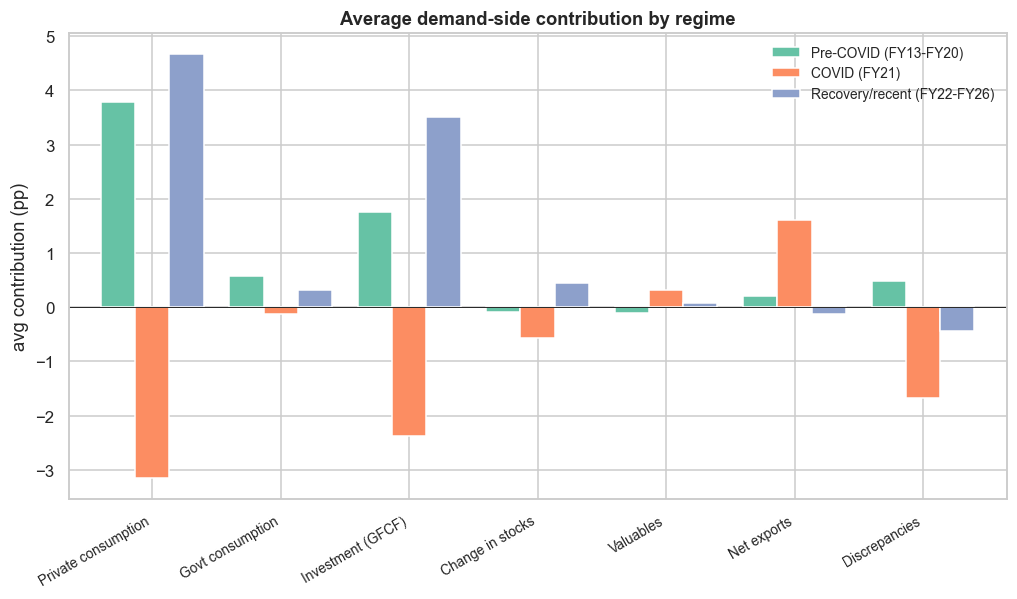

In [8]:
def regime(q):
    y = int(q[:4])
    if y <= 2019: return "Pre-COVID (FY13-FY20)"
    if y == 2020: return "COVID (FY21)"
    return "Recovery/recent (FY22-FY26)"
g["regime"] = g["FY_Quarter"].map(regime)
order = ["Pre-COVID (FY13-FY20)","COVID (FY21)","Recovery/recent (FY22-FY26)"]
avg = g.groupby("regime")[COMPONENTS].mean().reindex(order).rename(columns=NICE)
avg["GDP growth"] = g.groupby("regime")["GDP_growth_pct"].mean().reindex(order)
print(avg.round(2).T.to_string())

fig, ax = plt.subplots(figsize=(11, 5.5))
avg[list(NICE.values())].T.plot(kind="bar", ax=ax, color=sns.color_palette("Set2", 3), width=0.8)
ax.axhline(0, color="k", lw=0.6)
ax.set_ylabel("avg contribution (pp)"); ax.set_xlabel("")
ax.set_xticklabels(list(NICE.values()), rotation=30, ha="right", fontsize=9)
ax.legend(frameon=False, fontsize=9)
ax.set_title("Average demand-side contribution by regime")
fig.savefig(FIGS/"03c_contributions_by_regime.png"); plt.show()

## 3 · Accounting contributions vs model drivers — why they differ
A natural question: notebook 02 said **IIP / investment** were the top *predictors*, but the
biggest *contributor* here is usually **private consumption (PFCE)**. Both are correct — they
answer different questions:

- **Contribution (this notebook)** = share-of-GDP × its own growth. PFCE is ~55-60% of GDP,
  so even modest PFCE growth contributes the most percentage points. It's an *accounting*
  share of what already happened.
- **Predictive importance (notebook 02)** = how much a variable helps *forecast* growth at
  the margin. Consumption is large but smooth and partly predictable from GDP's own past;
  industrial production and investment carry more *new* information quarter to quarter.

So: PFCE *accounts for* the most growth; IIP/GFCF best *predict* changes in it. Stating this
distinction is the sophisticated answer to "which factor matters most".

Average contribution to GDP growth, FY13-FY26 (pp):
Private consumption    3.56
Investment (GFCF)      2.03
Govt consumption       0.44
Net exports            0.20
Change in stocks       0.06
Discrepancies          0.02
Valuables             -0.02

Model's top predictors (from notebook 02 consensus): IIP_growth, GFCF_YoY, FiscalDeficit, CrudeINR_YoY  -> different question, different answer.


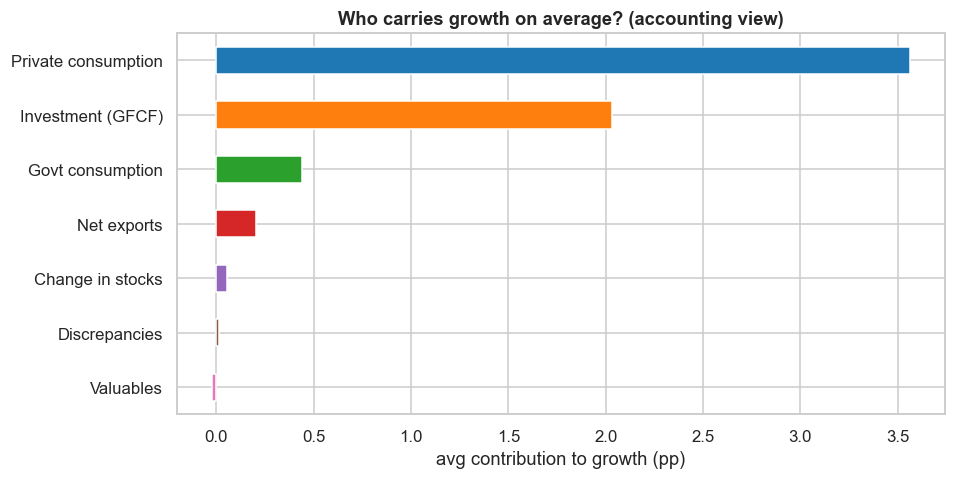

In [9]:
# Side-by-side: average accounting share vs (recall) the model's top predictors.
mean_contrib = g[COMPONENTS].mean().rename(index=NICE).sort_values(ascending=False)
print("Average contribution to GDP growth, FY13-FY26 (pp):")
print(mean_contrib.round(2).to_string())
print("\nModel's top predictors (from notebook 02 consensus): IIP_growth, GFCF_YoY, "
      "FiscalDeficit, CrudeINR_YoY  -> different question, different answer.")

fig, ax = plt.subplots(figsize=(9, 4.5))
mean_contrib.iloc[::-1].plot.barh(ax=ax, color=sns.color_palette("tab10", len(COMPONENTS))[::-1])
ax.set_xlabel("avg contribution to growth (pp)")
ax.set_title("Who carries growth on average? (accounting view)")
fig.savefig(FIGS/"03d_avg_contribution.png"); plt.show()

## 4 · A note on the discrepancy term
The `Discrepancies` contribution is large and swings sign quarter to quarter (it's the gap
between the production and expenditure estimates of GDP). MoSPI's own commentary flags that
discrepancies grew under the new methodology. Practically: when discrepancies are big, read
the *consumption + investment + net-exports* core rather than any single quarter's headline,
because the residual is doing a lot of the moving.

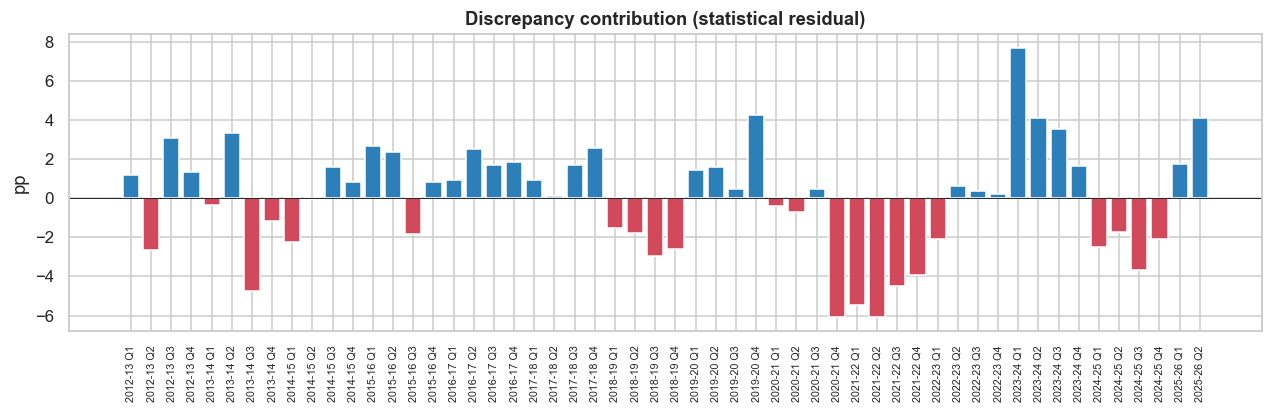

Discrepancy contribution: mean 0.02 pp, std 2.85 pp, range [-6.08, 7.70]


In [10]:
disc = g[["FY_Quarter","c_Discrepancies"]].copy()
fig, ax = plt.subplots(figsize=(14, 3.5))
colors = ["#d1495b" if v < 0 else "#2c7fb8" for v in disc["c_Discrepancies"]]
ax.bar(range(len(disc)), disc["c_Discrepancies"], color=colors)
ax.axhline(0, color="k", lw=0.6)
ax.set_xticks(range(len(disc))); ax.set_xticklabels(disc["FY_Quarter"], rotation=90, fontsize=7)
ax.set_ylabel("pp"); ax.set_title("Discrepancy contribution (statistical residual)")
fig.savefig(FIGS/"03e_discrepancy.png"); plt.show()
print(f"Discrepancy contribution: mean {disc['c_Discrepancies'].mean():.2f} pp, "
      f"std {disc['c_Discrepancies'].std():.2f} pp, "
      f"range [{disc['c_Discrepancies'].min():.2f}, {disc['c_Discrepancies'].max():.2f}]")

## Project synthesis (notebooks 01 → 02 → 03)
- **01 EDA** cleaned a 60-quarter macro panel, justified modelling growth/YoY forms
  (stationarity), and pruned collinear features with VIF.
- **02 Forecasting** showed that on ~55 quarters a random walk is hard to beat; the
  *interpretable* models name **IIP growth and investment** as the top predictors; and a
  **SARIMA + COVID-dummy** forecast puts **FY2026-27 Q1 ≈ 7.1%, Q2 ≈ 6.1%** (80% band).
- **03 Contributions** decomposed realised growth: **private consumption carries the most**,
  investment is the steady second engine, and the discrepancy term is large and noisy.
- **Cross-cutting:** the 2011-12 → 2022-23 base revision is handled throughout (spliced
  target, base-sensitivity check), which is the project's distinctive contribution.

The honest headline: *consumption accounts for most of India's growth, investment and
industrial activity best predict its near-term changes, and the answer is mildly sensitive to
the 2026 base-year revision — so we report it with that caveat.*